#Projeto III – Métodos Numéricos
#Busca de raízes de equações não lineares usando Gradiente Descendente e Métodos Clássicos
#Disciplina: Métodos Numéricos

#Aluno: Keviny Ryan Menezes Dantas

1. Introdução

---

Este projeto apresenta um estudo comparativo entre o Método do Gradiente Descendente e os métodos tradicionais de busca de raízes (Bisseção, Ponto Fixo, Newton-Raphson e Secante)111. O objetivo é avaliar a robustez e a eficiência do gradiente descendente ao transformar o problema de encontrar raízes em um problema de otimização, minimizando a função de custo $J(x) = f(x)^2$.

2. Implementação dos Métodos Clássicos


---

Estes métodos foram recuperados da atividade anterior para servirem de base comparativa.

In [ ]:
import numpy as np
import time
import matplotlib.pyplot as plt

# --- 1. Método da Bisseção ---
def metodo_bissecao(f, a, b, tol, max_iter=200):
    start_time = time.time()
    if f(a) * f(b) >= 0: return None, 0, False, 0.0
    for i in range(1, max_iter + 1):
        c = (a + b) / 2
        if (b - a) / 2 < tol or abs(f(c)) < tol:
            return c, i, True, time.time() - start_time
        if f(a) * f(c) < 0: b = c
        else: a = c
    return c, max_iter, False, time.time() - start_time

# --- 2. Método do Ponto Fixo ---
def metodo_ponto_fixo(g, x0, tol, max_iter=200):
    start_time = time.time()
    x_ant = x0
    for i in range(1, max_iter + 1):
        x_novo = g(x_ant)
        if abs(x_novo - x_ant) < tol:
            return x_novo, i, True, time.time() - start_time
        x_ant = x_novo
    return x_ant, max_iter, False, time.time() - start_time

# --- 3. Método de Newton-Raphson ---
def metodo_newton(f, df, x0, tol, max_iter=200):
    start_time = time.time()
    x_ant = x0
    for i in range(1, max_iter + 1):
        derivada = df(x_ant)
        if derivada == 0: break
        x_novo = x_ant - (f(x_ant) / derivada)
        if abs(x_novo - x_ant) < tol:
            return x_novo, i, True, time.time() - start_time
        x_ant = x_novo
    return x_ant, max_iter, False, time.time() - start_time

# --- 4. Método da Secante ---
def metodo_secante(f, x0, x1, tol, max_iter=200):
    start_time = time.time()
    for i in range(1, max_iter + 1):
        fx0, fx1 = f(x0), f(x1)
        if (fx1 - fx0) == 0: break
        x_novo = x1 - (fx1 * (x1 - x0)) / (fx1 - fx0)
        if abs(x_novo - x1) < tol:
            return x_novo, i, True, time.time() - start_time
        x0, x1 = x1, x_novo
    return x1, max_iter, False, time.time() - start_time

3. Implementação do Gradiente Descendente e Visualização

---

O gradiente descendente utiliza a direção oposta ao gradiente para encontrar o mínimo da função de custo $J(x)$4.

In [ ]:
def gradiente_descendente_com_historico(f, df, x0, alpha=0.01, tol=1e-10, max_iter=1000):
    x = x0
    historico_j = []
    start_time = time.time()

    for i in range(max_iter):
        custo = f(x)**2
        historico_j.append(custo)

        # Gradiente: d/dx [f(x)^2] = 2 * f(x) * f'(x)
        gradiente = 2 * f(x) * df(x)
        x_novo = x - alpha * gradiente

        if abs(x_novo - x) < tol or custo < tol:
            return x_novo, i+1, True, time.time() - start_time, historico_j
        x = x_novo

    return x, max_iter, False, time.time() - start_time, historico_j

def plotar_convergencia(historico):
    plt.figure(figsize=(10, 5))
    plt.plot(historico, label='Custo $J(x) = f(x)^2$')
    plt.yscale('log')
    plt.xlabel('Iterações')
    plt.ylabel('Custo (Escala Log)')
    plt.title('Convergência do Gradiente Descendente')
    plt.grid(True)
    plt.legend()
    plt.show()

4. Testes e Comparativos: Função $f_4(x)

---

Para este teste, utilizamos a função anteriormente trabalhada::$f_{4}(x) = \sin(x)x + 4$ com $x^{*} \in [1, 5]$6.

Método               Raiz            Iterações  Tempo (s)       Conv
----------------------------------------------------------------------
Bisseção             4.32323954      34         0.000264        True
Ponto Fixo           4.32323954      31         0.000077        True
Newton               4.32323954      5          0.000052        True
Secante              4.32323954      8          0.000045        True
Gradiente Desc.      4.32323640      78         0.000540        True


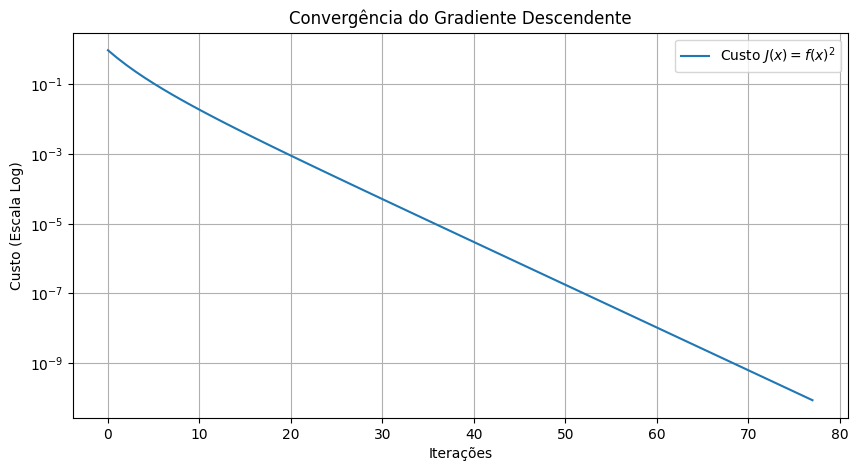

In [ ]:
def f4(x): return np.sin(x)*x + 4
def df4(x): return np.sin(x) + x*np.cos(x)
def g4(x): return x + (np.sin(x)*x + 4)/5 # Função de iteração para Ponto Fixo

tol = 1e-10
x0 = 4.0

print(f"{'Método':<20} {'Raiz':<15} {'Iterações':<10} {'Tempo (s)':<15} {'Conv'}")
print("-" * 70)

# Executando métodos clássicos
r, it, conv, t = metodo_bissecao(f4, 1, 5, tol)
print(f"{'Bisseção':<20} {r:<15.8f} {it:<10} {t:<15.6f} {conv}")

r, it, conv, t = metodo_ponto_fixo(g4, x0, tol)
print(f"{'Ponto Fixo':<20} {r:<15.8f} {it:<10} {t:<15.6f} {conv}")

r, it, conv, t = metodo_newton(f4, df4, x0, tol)
print(f"{'Newton':<20} {r:<15.8f} {it:<10} {t:<15.6f} {conv}")

r, it, conv, t = metodo_secante(f4, 1, 5, tol)
print(f"{'Secante':<20} {r:<15.8f} {it:<10} {t:<15.6f} {conv}")

# Executando Gradiente Descendente
r_gd, it_gd, conv_gd, t_gd, hist = gradiente_descendente_com_historico(f4, df4, x0, alpha=0.01)
print(f"{'Gradiente Desc.':<20} {r_gd:<15.8f} {it_gd:<10} {t_gd:<15.6f} {conv_gd}")

# Plotando o gráfico de custo do GD
plotar_convergencia(hist)

5. Discussão dos Resultados


---

Conforme observado no gráfico e na tabela comparativa:

Convergência: O Método de Newton continua sendo o mais rápido em termos de iterações (5 iterações para $f_4$)7. O Gradiente Descendente apresenta uma descida consistente na função de custo, mas a velocidade depende fortemente da taxa de aprendizagem $\alpha$888.

Eficiência: O Gradiente Descendente exige o cálculo da derivada, assim como o método de Newton, mas por ser um método de primeira ordem, pode levar mais iterações para atingir a mesma precisão em escalas de tolerância finas ($10^{-10}$)9.

Gráfico de Custo: A visualização em escala logarítmica mostra que o Gradiente Descendente reduz o erro de forma exponencial nas primeiras iterações, tendendo a estabilizar conforme se aproxima da raiz (mínimo global de $J(x)$)10.

6. Conclusão


---


A integração dos métodos clássicos com o gradiente descendente permitiu observar que, embora o gradiente descendente seja robusto e amplamente utilizado em otimização complexa 11, para funções unidimensionais simples, os métodos de Newton e Secante ainda oferecem uma convergência superior em termos de velocidade12. Contudo, a facilidade de monitorar a convergência através do gráfico da função de custo $J(x)$ é uma vantagem didática e prática significativa do gradiente descendente.